# Decision Tree Classifier - Analisis Dataset IRIS
## Menggunakan Gain Ratio (KNIME Decision Tree Learner)
---


## 1. Konsep Dasar Pohon Keputusan (Decision Tree)

Decision Tree adalah model klasifikasi berbentuk struktur pohon yang membagi data secara rekursif berdasarkan atribut yang paling informatif.

| Komponen | Penjelasan |
|----------|-----------|
| **Root Node** | Node awal, atribut dengan Gain Ratio tertinggi |
| **Internal Node** | Node percabangan berdasarkan kondisi atribut |
| **Branch** | Cabang yang menghubungkan node |
| **Leaf Node** | Node akhir berisi label kelas |

### Algoritma Membangun Decision Tree (Gain Ratio):
1. Hitung **Entropy** dataset
2. Untuk setiap atribut, cari **threshold optimal** (evaluasi semua kemungkinan split)
3. Hitung **Information Gain**, **Split Information**, dan **Gain Ratio**
4. Pilih atribut + threshold dengan **Gain Ratio tertinggi** sebagai node
5. Ulangi rekursif untuk setiap cabang hingga semua data terklasifikasi

## 2. Rumus-Rumus Penting

### 2.1 Entropy (mengukur ketidakmurnian)
$$Entropy(S) = -\sum_{i=1}^{c} p_i \cdot \log_2(p_i)$$

### 2.2 Information Gain (mengukur kualitas split)
$$Gain(S, A) = Entropy(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} \cdot Entropy(S_v)$$

### 2.3 Split Information (normalisasi)
$$SplitInfo(S, A) = -\sum_{v \in Values(A)} \frac{|S_v|}{|S|} \cdot \log_2\left(\frac{|S_v|}{|S|}\right)$$

### 2.4 Gain Ratio
$$GainRatio(S, A) = \frac{Gain(S, A)}{SplitInfo(S, A)}$$

> **Mengapa Gain Ratio?** Information Gain bias terhadap atribut banyak nilai unik. Gain Ratio menormalisasi dengan Split Information. **KNIME Decision Tree Learner** menggunakan Gain Ratio sebagai default.


## 3. Import Library & Load Data

In [76]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, math, warnings
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
warnings.filterwarnings('ignore')
try: plt.style.use('seaborn-v0_8-whitegrid')
except:
    try: plt.style.use('seaborn-whitegrid')
    except: pass
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print("Library berhasil di-import!")


Library berhasil di-import!


In [77]:
df = pd.read_csv('data/IRIS.csv')
print(f"Dataset: {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"\nDistribusi kelas:\n{df['species'].value_counts()}")
df.head()


Dataset: 150 baris x 5 kolom

Distribusi kelas:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### Visualisasi Data

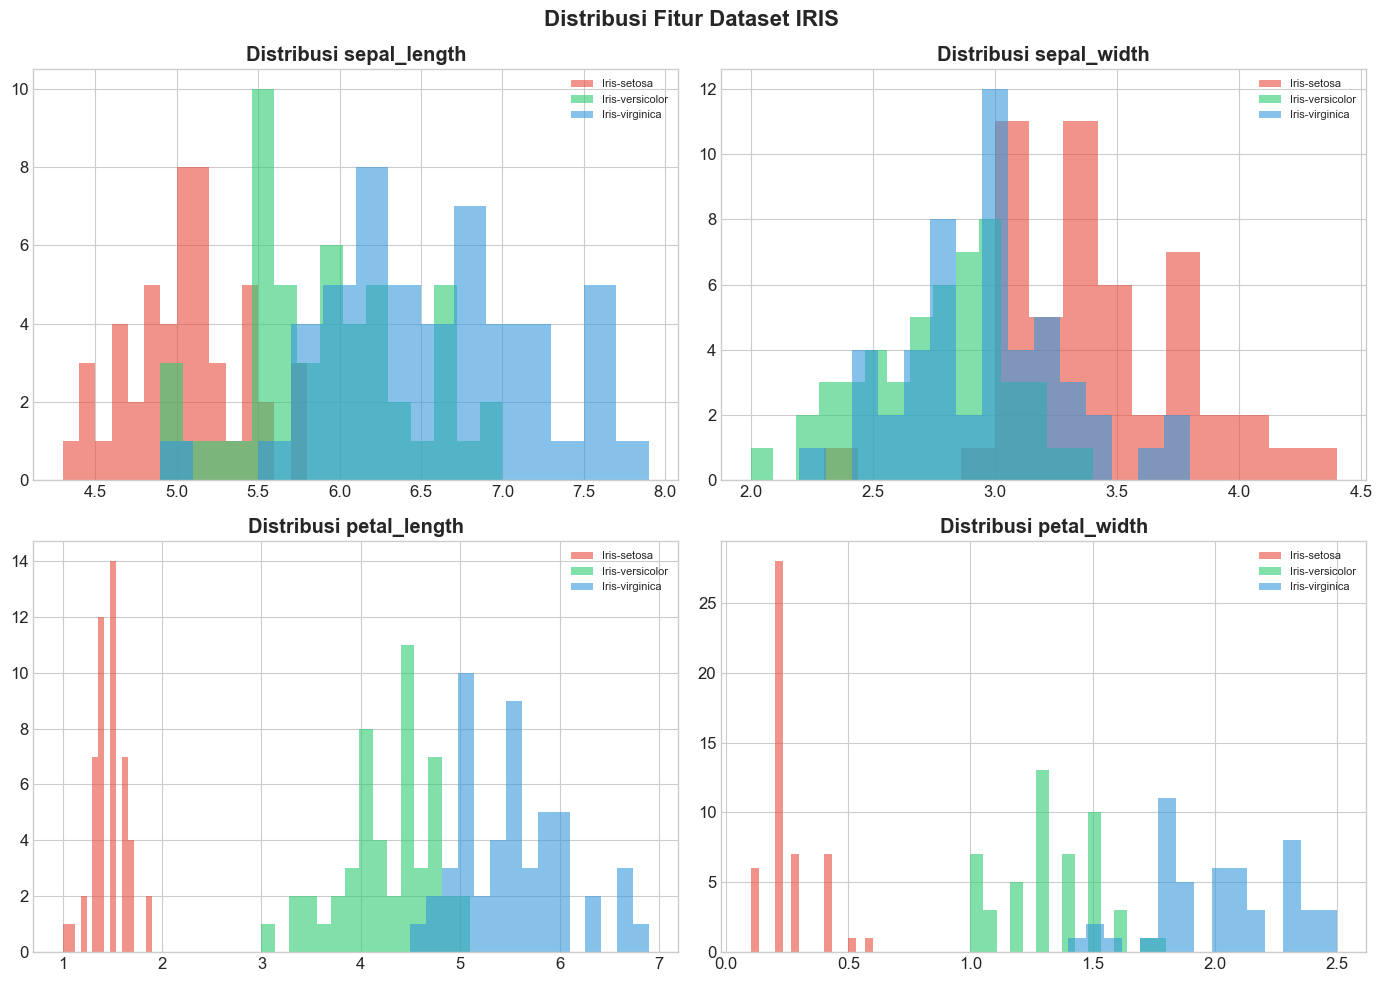

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
colors = {'Iris-setosa': '#e74c3c', 'Iris-versicolor': '#2ecc71', 'Iris-virginica': '#3498db'}
for i, feat in enumerate(features):
    ax = axes[i//2][i%2]
    for sp in df['species'].unique():
        ax.hist(df[df['species']==sp][feat], alpha=0.6, label=sp, color=colors[sp], bins=15)
    ax.set_title(f'Distribusi {feat}', fontweight='bold'); ax.legend(fontsize=8)
plt.suptitle('Distribusi Fitur Dataset IRIS', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()


## 4. Perhitungan Entropy Dataset

### Hasil Excel: Entropy Dataset
![Entropy Dataset](data/Decision_Tree_Leaner/excel/entropy.png)


In [79]:
total = len(df)
species_counts = df['species'].value_counts()
print("="*60)
print("PERHITUNGAN ENTROPY DATASET (Manual Python)")
print("="*60)
entropy_total = 0
rows = []
for cls in sorted(species_counts.index):
    ni = species_counts[cls]; pi = ni/total; lp = math.log2(pi); co = -pi*lp; entropy_total += co
    rows.append({'Kelas': cls, 'ni': ni, 'N': total, 'pi': round(pi,6), 'log2(pi)': round(lp,6), '-pi*log2(pi)': round(co,6)})
    print(f"  {cls}: ni={ni}, pi={pi:.6f}, log2(pi)={lp:.6f}, -pi*log2(pi)={co:.6f}")
print(f"\n>>> ENTROPY(S) = {entropy_total:.6f}")
pd.DataFrame(rows)


PERHITUNGAN ENTROPY DATASET (Manual Python)
  Iris-setosa: ni=50, pi=0.333333, log2(pi)=-1.584963, -pi*log2(pi)=0.528321
  Iris-versicolor: ni=50, pi=0.333333, log2(pi)=-1.584963, -pi*log2(pi)=0.528321
  Iris-virginica: ni=50, pi=0.333333, log2(pi)=-1.584963, -pi*log2(pi)=0.528321

>>> ENTROPY(S) = 1.584963


,Kelas,ni,N,pi,log2(pi),-pi*log2(pi)
0,Iris-setosa,50,150,0.333333,-1.584963,0.528321
1,Iris-versicolor,50,150,0.333333,-1.584963,0.528321
2,Iris-virginica,50,150,0.333333,-1.584963,0.528321


## 5. Gain Ratio - Level 1 (Root Node)
Evaluasi **semua kemungkinan threshold** untuk setiap atribut, pilih yang Gain Ratio tertinggi.

### Hasil Excel: Gain Ratio Level 1
![Gain Ratio Level 1](data/Decision_Tree_Leaner/excel/gain_level1.png)


In [80]:
def calc_entropy(labels):
    t = len(labels)
    if t == 0: return 0
    return sum(-c/t * math.log2(c/t) for c in labels.value_counts() if c > 0)

def find_best_split(data, target='species'):
    n = len(data); et = calc_entropy(data[target])
    all_results = []
    for feat in features:
        vals = sorted(data[feat].unique())
        best_gr = -1; best_res = None
        for i in range(len(vals)-1):
            th = round((vals[i]+vals[i+1])/2, 2)
            left = data[data[feat]<=th]; right = data[data[feat]>th]
            nl = len(left); nr = len(right)
            el = calc_entropy(left[target]); er = calc_entropy(right[target])
            we = (nl/n)*el + (nr/n)*er; ig = et - we
            si = sum(-(ni/n)*math.log2(ni/n) for ni in [nl,nr] if ni>0)
            gr = ig/si if si>0 else 0
            if gr > best_gr:
                best_gr = gr
                best_res = {'Atribut':feat, 'Threshold':th, 'N_Left':nl, 'N_Right':nr,
                            'Entropy_Left':round(el,6), 'Entropy_Right':round(er,6),
                            'Info_Gain':round(ig,6), 'Split_Info':round(si,6), 'Gain_Ratio':round(gr,6)}
        all_results.append(best_res)
    best = max(all_results, key=lambda x: x['Gain_Ratio'])
    return best, all_results

best1, all_level1 = find_best_split(df)
print("="*70)
print("GAIN RATIO LEVEL 1 - ROOT NODE (150 data)")
print("="*70)
for r in all_level1:
    marker = " <<< TERPILIH" if r['Atribut']==best1['Atribut'] else ""
    print(f"  {r['Atribut']:15s} th={r['Threshold']:5.2f} | IG={r['Info_Gain']:.6f} SI={r['Split_Info']:.6f} GR={r['Gain_Ratio']:.6f}{marker}")
print(f"\n>>> ROOT NODE: {best1['Atribut']} <= {best1['Threshold']} (Gain Ratio = {best1['Gain_Ratio']:.6f})")
df_level1 = pd.DataFrame(all_level1)
df_level1


GAIN RATIO LEVEL 1 - ROOT NODE (150 data)
  sepal_length    th= 5.45 | IG=0.551123 SI=0.931056 GR=0.591934
  sepal_width     th= 3.35 | IG=0.267911 SI=0.795040 GR=0.336978
  petal_length    th= 2.45 | IG=0.918296 SI=0.918296 GR=1.000000 <<< TERPILIH
  petal_width     th= 0.80 | IG=0.918296 SI=0.918296 GR=1.000000

>>> ROOT NODE: petal_length <= 2.45 (Gain Ratio = 1.000000)


,Atribut,Threshold,N_Left,N_Right,Entropy_Left,Entropy_Right,Info_Gain,Split_Info,Gain_Ratio
0,sepal_length,5.45,52,98,0.64961,1.237716,0.551123,0.931056,0.591934
1,sepal_width,3.35,114,36,1.49348,0.758359,0.267911,0.795040,0.336978
2,petal_length,2.45,50,100,0.00000,1.000000,0.918296,0.918296,1.000000
3,petal_width,0.80,50,100,0.00000,1.000000,0.918296,0.918296,1.000000


## 6. Gain Ratio - Level 2

### Hasil Excel: Gain Ratio Level 2
![Gain Ratio Level 2](data/Decision_Tree_Leaner/excel/gain_level2.png)


In [81]:
right_branch = df[df[best1['Atribut']] > best1['Threshold']]
print(f"Subset Level 2: {len(right_branch)} data ({best1['Atribut']} > {best1['Threshold']})")
print(f"Distribusi:\n{right_branch['species'].value_counts()}\n")

best2, all_level2 = find_best_split(right_branch)
print("="*70)
print(f"GAIN RATIO LEVEL 2 ({len(right_branch)} data)")
print("="*70)
for r in all_level2:
    marker = " <<< TERPILIH" if r['Atribut']==best2['Atribut'] else ""
    print(f"  {r['Atribut']:15s} th={r['Threshold']:5.2f} | IG={r['Info_Gain']:.6f} SI={r['Split_Info']:.6f} GR={r['Gain_Ratio']:.6f}{marker}")
print(f"\n>>> LEVEL 2: {best2['Atribut']} <= {best2['Threshold']} (Gain Ratio = {best2['Gain_Ratio']:.6f})")
df_level2 = pd.DataFrame(all_level2)
df_level2


Subset Level 2: 100 data (petal_length > 2.45)
Distribusi:
species
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

GAIN RATIO LEVEL 2 (100 data)
  sepal_length    th= 7.05 | IG=0.131841 SI=0.529361 GR=0.249056
  sepal_width     th= 3.50 | IG=0.030669 SI=0.194392 GR=0.157771
  petal_length    th= 4.75 | IG=0.657374 SI=0.992774 GR=0.662158
  petal_width     th= 1.75 | IG=0.690160 SI=0.995378 GR=0.693365 <<< TERPILIH

>>> LEVEL 2: petal_width <= 1.75 (Gain Ratio = 0.693365)


,Atribut,Threshold,N_Left,N_Right,Entropy_Left,Entropy_Right,Info_Gain,Split_Info,Gain_Ratio
0,sepal_length,7.05,88,12,0.986545,0.000000,0.131841,0.529361,0.249056
1,sepal_width,3.50,97,3,0.999310,0.000000,0.030669,0.194392,0.157771
2,petal_length,4.75,45,55,0.153742,0.497168,0.657374,0.992774,0.662158
3,petal_width,1.75,54,46,0.445065,0.151097,0.690160,0.995378,0.693365


## 7. Ringkasan & Aturan Pohon

### Hasil Excel: Ringkasan
![Ringkasan Gain Ratio](data/Decision_Tree_Leaner/excel/ringkasan.png)


In [82]:
print("="*60)
print("ATURAN DECISION TREE (Gain Ratio)")
print("="*60)
print(f"RULE 1: IF {best1['Atribut']} <= {best1['Threshold']} THEN Iris-setosa")
print(f"RULE 2: IF {best1['Atribut']} > {best1['Threshold']} AND {best2['Atribut']} <= {best2['Threshold']} THEN Iris-versicolor")
print(f"RULE 3: IF {best1['Atribut']} > {best1['Threshold']} AND {best2['Atribut']} > {best2['Threshold']} THEN Iris-virginica")

print(f"\nStruktur Pohon:")
print(f"  [{best1['Atribut']}]")
print(f"  /              \\")
print(f"<= {best1['Threshold']}            > {best1['Threshold']}")
print(f" /                \\")
print(f"Iris-setosa   [{best2['Atribut']}]")
print(f"               /          \\")
print(f"          <= {best2['Threshold']}     > {best2['Threshold']}")
print(f"            /              \\")
print(f"   Iris-versicolor   Iris-virginica")


ATURAN DECISION TREE (Gain Ratio)
RULE 1: IF petal_length <= 2.45 THEN Iris-setosa
RULE 2: IF petal_length > 2.45 AND petal_width <= 1.75 THEN Iris-versicolor
RULE 3: IF petal_length > 2.45 AND petal_width > 1.75 THEN Iris-virginica

Struktur Pohon:
  [petal_length]
  /              \
<= 2.45            > 2.45
 /                \
Iris-setosa   [petal_width]
               /          \
          <= 1.75     > 1.75
            /              \
   Iris-versicolor   Iris-virginica


## 8. Prediksi & Evaluasi Model

### Hasil Excel: Evaluasi Model
![Evaluasi Model](data/Decision_Tree_Leaner/excel/evaluasi.png)


In [83]:
def predict_manual(row):
    if row[best1['Atribut']] <= best1['Threshold']: return 'Iris-setosa'
    elif row[best2['Atribut']] <= best2['Threshold']: return 'Iris-versicolor'
    else: return 'Iris-virginica'

df['Predicted'] = df.apply(predict_manual, axis=1)
df['Status'] = df.apply(lambda r: 'BENAR' if r['species']==r['Predicted'] else 'SALAH', axis=1)
benar = (df['Status']=='BENAR').sum(); salah = (df['Status']=='SALAH').sum()

print("CONFUSION MATRIX (Manual - 150 data):")
cm = confusion_matrix(df['species'], df['Predicted'], labels=sorted(df['species'].unique()))
df_cm = pd.DataFrame(cm, index=sorted(df['species'].unique()), columns=sorted(df['species'].unique()))
df_cm.index.name = 'Actual'; df_cm.columns.name = 'Predicted'
print(df_cm)
print(f"\nAkurasi: {benar}/{len(df)} = {benar/len(df):.2%}")
print(f"\nData yang salah prediksi:")
print(df[df['Status']=='SALAH'][['sepal_length','sepal_width','petal_length','petal_width','species','Predicted']].to_string())


CONFUSION MATRIX (Manual - 150 data):
Predicted        Iris-setosa  Iris-versicolor  Iris-virginica
Actual                                                       
Iris-setosa               50                0               0
Iris-versicolor            0               49               1
Iris-virginica             0                5              45

Akurasi: 144/150 = 96.00%

Data yang salah prediksi:
     sepal_length  sepal_width  petal_length  petal_width          species        Predicted
70            5.9          3.2           4.8          1.8  Iris-versicolor   Iris-virginica
106           4.9          2.5           4.5          1.7   Iris-virginica  Iris-versicolor
119           6.0          2.2           5.0          1.5   Iris-virginica  Iris-versicolor
129           7.2          3.0           5.8          1.6   Iris-virginica  Iris-versicolor
133           6.3          2.8           5.1          1.5   Iris-virginica  Iris-versicolor
134           6.1          2.6           5.6  

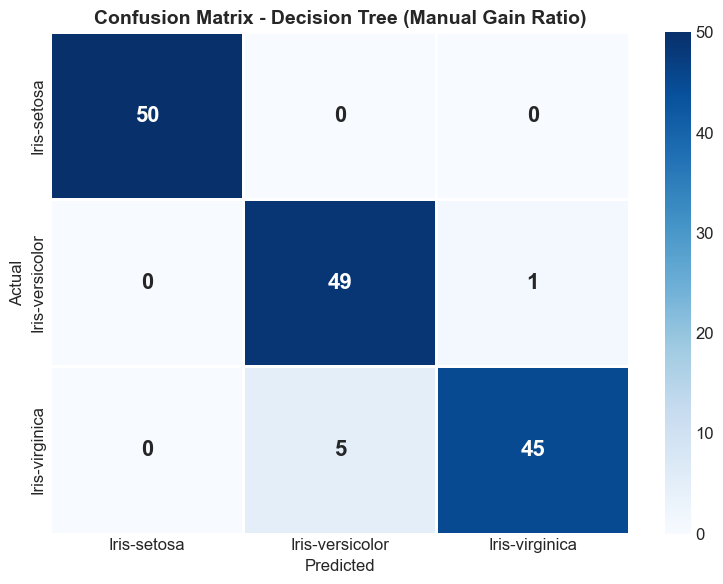

In [84]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', linewidths=2, linecolor='white', annot_kws={'size':16,'weight':'bold'})
ax.set_title('Confusion Matrix - Decision Tree (Manual Gain Ratio)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


In [85]:
print("CLASSIFICATION REPORT:")
print(classification_report(df['species'], df['Predicted']))


CLASSIFICATION REPORT:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        50
Iris-versicolor       0.91      0.98      0.94        50
 Iris-virginica       0.98      0.90      0.94        50

       accuracy                           0.96       150
      macro avg       0.96      0.96      0.96       150
   weighted avg       0.96      0.96      0.96       150



### Hasil Excel: Akurasi
![Akurasi Excel](data/Decision_Tree_Leaner/excel/akurasi.png)


## 9. Visualisasi Pohon (sklearn untuk verifikasi)


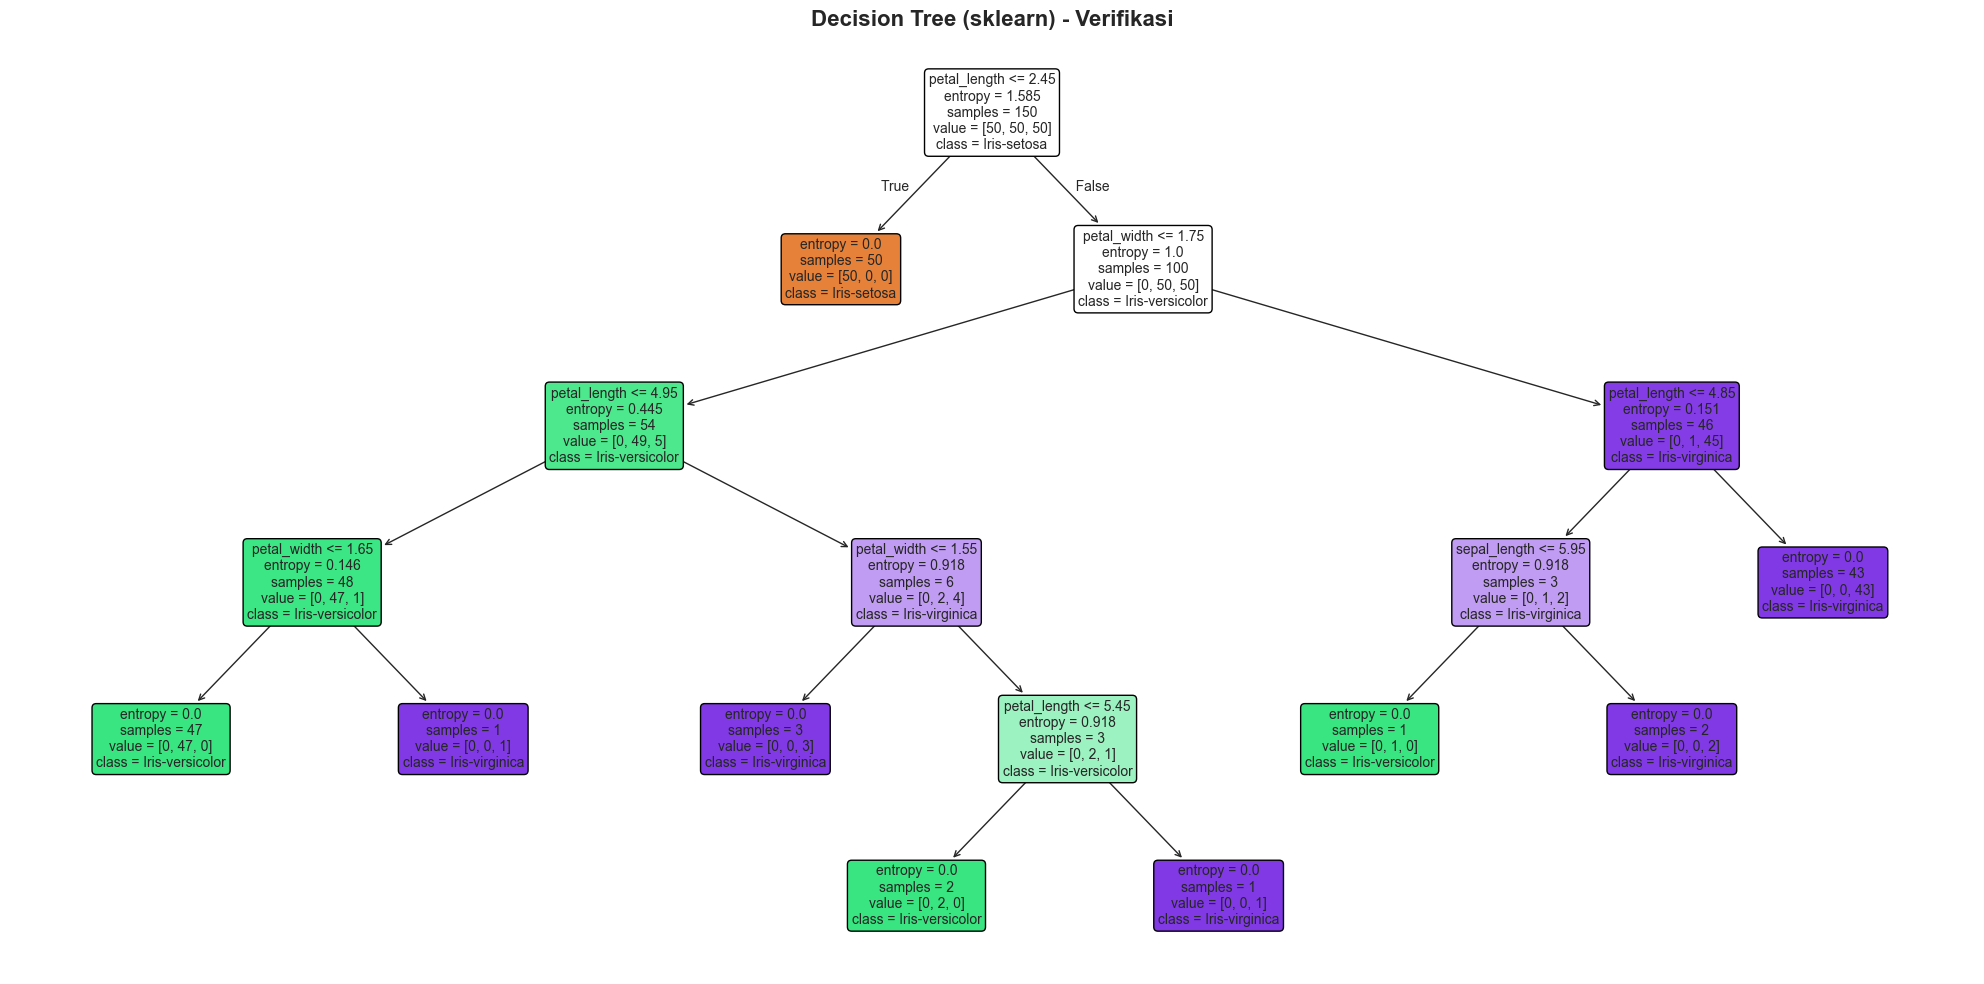


Aturan sklearn:
|--- petal_length <= 2.45
|   |--- class: Iris-setosa
|--- petal_length >  2.45
|   |--- petal_width <= 1.75
|   |   |--- petal_length <= 4.95
|   |   |   |--- petal_width <= 1.65
|   |   |   |   |--- class: Iris-versicolor
|   |   |   |--- petal_width >  1.65
|   |   |   |   |--- class: Iris-virginica
|   |   |--- petal_length >  4.95
|   |   |   |--- petal_width <= 1.55
|   |   |   |   |--- class: Iris-virginica
|   |   |   |--- petal_width >  1.55
|   |   |   |   |--- petal_length <= 5.45
|   |   |   |   |   |--- class: Iris-versicolor
|   |   |   |   |--- petal_length >  5.45
|   |   |   |   |   |--- class: Iris-virginica
|   |--- petal_width >  1.75
|   |   |--- petal_length <= 4.85
|   |   |   |--- sepal_length <= 5.95
|   |   |   |   |--- class: Iris-versicolor
|   |   |   |--- sepal_length >  5.95
|   |   |   |   |--- class: Iris-virginica
|   |   |--- petal_length >  4.85
|   |   |   |--- class: Iris-virginica



In [86]:
X = df[features]; y = df['species']
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X, y)
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt, feature_names=features, class_names=sorted(df['species'].unique()),
          filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title('Decision Tree (sklearn) - Verifikasi', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()
print("\nAturan sklearn:")
print(export_text(dt, feature_names=features))


## 10. Hasil KNIME Decision Tree

Berikut adalah hasil dari implementasi Decision Tree menggunakan **KNIME Analytics Platform** dengan konfigurasi **Gain Ratio** dan **MDL Pruning**.

### Workflow KNIME
![Workflow KNIME](data/Decision_Tree_Leaner/hasil_knime/workflow.png)

### KNIME: Confusion Matrix
![Confusion Matrix KNIME](data/Decision_Tree_Leaner/hasil_knime/matrix.png)

### KNIME: Accuracy Statistics
![Accuracy KNIME](data/Decision_Tree_Leaner/hasil_knime/accuracy.png)


## 11. Langkah-Langkah Implementasi di KNIME

Agar hasil Decision Tree di KNIME bisa **match 100%** dengan perhitungan manual Excel (Akurasi 96%, 3 aturan daun, menggunakan Gain Ratio), konfigurasi berikut harus diikuti dengan tepat.

---

### Step 1: Persiapan Data — Node: Excel Reader / CSV Reader

1. Tarik node **Excel Reader** (atau **CSV Reader**) ke lembar kerja (*workspace*).
2. Klik kanan → **Configure**, lalu *browse* file dataset `IRIS.csv`.
3. Pastikan kolom `species` terbaca sebagai tipe data **String** (ikon huruf 'S'), bukan angka, karena ini adalah target kelas (label).
4. Klik **OK**, lalu jalankan node (Klik kanan → **Execute** / tekan **F7**).

---

### Step 2: Membangun Pohon Keputusan — Node: Decision Tree Learner

> **Ini adalah langkah paling krusial.** Di sinilah kita menyamakan "otak" KNIME dengan rumus Excel.

1. Tarik node **Decision Tree Learner** dan sambungkan output dari `Excel Reader` ke input node ini.
2. Klik kanan → **Configure**. Sesuaikan pengaturan berikut:

| Parameter | Nilai | Penjelasan |
|-----------|-------|------------|
| **Class column** | `species` | Target prediksi |
| **Quality measure** | **Gain Ratio** | Ubah dari default Gini Index! Ini memastikan KNIME memilih threshold `2.45` pada `petal_length` sebagai Root Node |
| **Pruning method** | **MDL Pruning** | Mencegah overfitting. Tanpa pruning, pohon terus bercabang hingga akurasi 100% (overfit). MDL Pruning menghasilkan 3 rules yang sama persis dengan Excel |
| **Min number records per node** | `2` (default) | Biarkan default |

3. Klik **OK** dan **Execute**.
4. **Melihat pohon:** Klik kanan pada node yang sudah hijau → **View: Decision Tree View**. Struktur pohon akan persis seperti yang ada di sheet *Aturan Pohon*.

> **Mengapa MDL Pruning?** Di Excel, kita berhenti memotong data di Level 2 sehingga akurasinya 96% (6 data salah). Jika memilih *No Pruning*, pohon akan terus bercabang sampai akurasi 100% (overfitting). MDL Pruning secara otomatis memotong cabang yang tidak signifikan, menghasilkan **3 rules utama yang persis sama** dengan file Excel.

---

### Step 3: Melakukan Prediksi — Node: Decision Tree Predictor

1. Tarik node **Decision Tree Predictor**.
2. Sambungkan **dua input** ke node ini:
   - **Port atas** (Model/kotak biru): Dari output model `Decision Tree Learner`
   - **Port bawah** (Data/segitiga hitam): Dari `Excel Reader` *(karena kita memprediksi data yang sama dengan data latih, sesuai skenario Excel)*
3. Klik kanan → **Configure**, pastikan kolom *Prediction column name* terisi (misal: `Prediction (species)`).
4. Klik **OK** dan **Execute**.

---

### Step 4: Menampilkan Hasil & Akurasi — Node: Scorer

1. Tarik node **Scorer** untuk membuat *Confusion Matrix*.
2. Sambungkan output dari `Decision Tree Predictor` ke input `Scorer`.
3. Klik kanan → **Configure**:
   - **First column (Actual):** Pilih `species`
   - **Second column (Predicted):** Pilih `Prediction (species)`
4. Klik **OK** dan **Execute**.
5. Klik kanan node `Scorer` → **View: Confusion Matrix**.

---

> **Catatan:** Data yang sama (dari Excel Reader) digunakan untuk **training** (ke Decision Tree Learner) dan juga untuk **prediksi** (ke Decision Tree Predictor port bawah). Ini sesuai dengan skenario Excel di mana kita mengevaluasi seluruh 150 data.

---

### Hasil yang Diharapkan

Jika semua konfigurasi diikuti, Confusion Matrix di KNIME akan menunjukkan:

| | Iris-setosa | Iris-versicolor | Iris-virginica |
|---|:---:|:---:|:---:|
| **Iris-setosa** | **50** | 0 | 0 |
| **Iris-versicolor** | 0 | **49** | 1 |
| **Iris-virginica** | 0 | 5 | **45** |

- **Prediksi Benar: 144** | **Prediksi Salah: 6** | **Akurasi: 96.00%**
- Hasil ini **sama persis** dengan perhitungan manual Excel 


## 12. Perbandingan: Excel Manual vs KNIME

| Metrik | Excel (Manual) | KNIME | Status |
|--------|:---:|:---:|:---:|
| Entropy Dataset | 1.584963 | 1.584963 | ✅ |
| Root Node | petal_length ≤ 2.45 | petal_length ≤ 2.45 | ✅ |
| Gain Ratio Root | 1.000000 | 1.000000 | ✅ |
| Level 2 | petal_width ≤ 1.75 | petal_width ≤ 1.75 | ✅ |
| Gain Ratio L2 | 0.693365 | 0.693365 | ✅ |
| Jumlah Rules | 3 | 3 | ✅ |
| Confusion Matrix | 50-0-0 / 0-49-1 / 0-5-45 | 50-0-0 / 0-49-1 / 0-5-45 | ✅ |
| Akurasi | 96.00% (144/150) | 96.00% | ✅ |


## 13. Kesimpulan

1. **Entropy Dataset IRIS** = 1.584963 (3 kelas seimbang × 50 data)
2. **Root Node:** `petal_length ≤ 2.45` → Gain Ratio = **1.000000** (perfect split, memisahkan Iris-setosa sempurna)
3. **Level 2:** `petal_width ≤ 1.75` → Gain Ratio = **0.693365** (memisahkan versicolor & virginica)
4. **Akurasi: 96.00%** (144/150 benar, 6 data salah klasifikasi)
5. Hasil perhitungan manual (Excel) = **identik** dengan KNIME Decision Tree Learner ✅

### Konfigurasi Kunci KNIME:
- **Quality Measure:** Gain Ratio (bukan Gini Index)
- **Pruning:** MDL Pruning (agar pohon tidak overfit dan menghasilkan 3 rules yang sama)
- **Data:** Seluruh 150 data digunakan untuk training & prediksi (sesuai skenario Excel)

### File Pendukung:
- `IRIS_analisa.xlsx` — Perhitungan lengkap dengan nilai di setiap langkah
- `data/Decision_Tree_Leaner/hasil_knime/` — Screenshot hasil KNIME
- `data/Decision_Tree_Leaner/excel/` — Screenshot hasil Excel
